# SI 313 WN26: Surveys Module Assignment
### Part B: Survey Data Analysis
##### Nick Pisarczyk - 03/25/26
---

## Introduction
- Research question and motivation
- Specific hypotheses you're testing

Choose ONE research question to investigate:

- Trust in institutions: What predicts trust in government institutions (Congress, presidency, media, science)? How do political affiliation, education, and demographic factors relate to institutional trust?
- Information sources and beliefs: How do different news sources (traditional media, social media, partisan outlets) relate to political knowledge, beliefs about factual matters, or policy preferences?
- Identity and political attitudes: How do different social identities (race, gender, education, religion, region) relate to political preferences? Are there interaction effects between identities?

### I chose: - Information sources and beliefs: How do different news sources (traditional media, social media, partisan outlets) relate to political knowledge, beliefs about factual matters, or policy preferences?
And I focused on the "political knowledge" aspect of the question

---

## Data Loading and Exploration
- Load ANES data
- Examine variables of interest
- Check missing data patterns
- Create necessary derived variables

In [182]:
# libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import chi2_contingency

In [183]:
# Load the 2020 ANES Time Series data
# df = pd.read_csv("/Users/libbyh/Documents/git/si313_instructors/answer_keys/data/38034-0001-Data.tsv", sep='\t')
df = pd.read_stata("../data/surveys_module_data/38034-0001-Data.dta", convert_categoricals=False)

# news/media sources
# rename variables with friendly names
df = df.rename(columns={
    "V201629A": "tv_used",                   # data about what media sources people heard anything about the presidential campaign from 
    "V201629B": "newspaper_used",            # covers traditional source use of radio/newspaper
    "V201629C": "internet_used",
    "V201629D": "radio_used",

    "V201630B": "sean_hannity_fox",          # partisan outlets      # watch hannity at least once a month
    "V201630C": "tucker_carlson_fox",                                # ... carlson ...
    "V201630D": "rachel_maddow_msnbc",                               # ... maddow ...
    "V201630E": "lawrence_odonnell_msnbc",                           # ... odonnell ...

    "V201634A": "yahoo_site",                # websites
    "V201634J": "bbc_site",
    "V201634P": "buzzfeed_site",

    "V201635A": "nyt_paper",                 # printed newspaper (traditional sources)
    "V201634B": "usa_today_paper",
    "V201634C": "wsj_paper",
    "V201634D": "wash_post_paper",

    "V202541A": "facebook",                  # social media platforms
    "V202541B": "twitter",
    "V202541C": "instagram",
    "V202541D": "reddit",
    "V202541E": "youtube",
    "V202541F": "snapchat",
    "V202541G": "tiktok",
})

# political knowledge
# rename variables with friendly names
df = df.rename(columns={
    "V201644": "senator_term",
    "V201645": "least_fed_spending",
    "V201646": "house_majority",
    "V201647": "senate_majority",
})

facts = ["senator_term", "least_fed_spending", "house_majority", "senate_majority"]
media = ["tv_used", "newspaper_used", "internet_used", "radio_used"]
partisan = ["sean_hannity_fox", "tucker_carlson_fox", "rachel_maddow_msnbc", "lawrence_odonnell_msnbc"]
websites = ["yahoo_site", "bbc_site", "buzzfeed_site"]
papers = ["nyt_paper", "usa_today_paper", "wsj_paper", "wash_post_paper"]
social_media = ["facebook", "twitter", "instagram", "reddit", "youtube", "snapchat", "tiktok"]
combined_vars = facts+media+partisan+websites+papers+social_media

model_df = df[combined_vars].dropna().copy()

print(model_df.head())

   senator_term  least_fed_spending  house_majority  senate_majority  tv_used  \
0             6                   3               1                2        1   
1             2                   4               2                1        1   
2             6                   1               1                2        1   
3             4                   1               2                1        1   
4             6                   1               1                2        1   

   newspaper_used  internet_used  radio_used  sean_hannity_fox  \
0               0              1           1                 0   
1               0              1           0                 0   
2               1              1           1                 0   
3               0              0           0                 0   
4               0              1           1                 0   

   tucker_carlson_fox  ...  usa_today_paper  wsj_paper  wash_post_paper  \
0                   0  ...               

In [184]:
# Recode factual knowledge questions to get binary right or wrong values
#       correct answers are 1
#       incorrect answers are 0
#       all others are NaN

model_df_recoded = model_df.copy()

def recode_factual_questions(column_name, correct_val):
    conditions = [
            df[column_name] == correct_val,
            df[column_name] > 0,
            df[column_name] < 0,
        ]
    choices = [
        1,
        0,
        np.nan,
    ]

    model_df_recoded[f"{column_name}"] = np.select(conditions, choices, default=model_df_recoded[column_name])
    # print(f"model_df column: {model_df[column_name]}")
    print(f"Unique values in column {column_name} are: {model_df_recoded[column_name].unique()}")

# more helper functions
def compare_desc_stats(column_name, correct_val):
    print(f"ORIGINAL VARS: Column {column_name}:\nCorrect Value = {correct_val}\n{model_df[column_name].value_counts(dropna=False)}\n")
    print(f"RECODED VARS: Column {column_name}:\nCorrect Value = 1.0\n{model_df_recoded[column_name].value_counts(dropna=False)}\n{'='*50}\n\n\n\n")

def compare_right_wrong_answers(column_name, correct_val):
    # need the correct answer, any NaNs, any incorrect
    # for first, need 6, any > 0 and not 6, any negative
    n_correct_before = (model_df[column_name] == correct_val).sum()
    n_incorrect_before = ((model_df[column_name] > 0) & ((model_df)[column_name] != correct_val)).sum()
    n_negative_before = (model_df[column_name] < 0).sum()

    # compare now to recoded
    n_correct_after = (model_df_recoded[column_name] == 1.0).sum()
    n_incorrect_after = (model_df_recoded[column_name] == 0.0).sum()
    n_negative_after = model_df_recoded[column_name].isna().sum()

    print(f"For column {column_name}:\nCorrect answers before / after recoding: {n_correct_before} / {n_correct_after}\nIncorrect answers before / after recoding: {n_incorrect_before} / {n_incorrect_after}\nNegative answers before / after recoding: {n_negative_before} / {n_negative_after}\n")

In [188]:
cols = {'senator_term':6, 'least_fed_spending':1, 'house_majority':1, 'senate_majority':2}
# for i in range(4,(len(combined_vars))):
#     cols[combined_vars[i]] = 1
# print(cols)

print(f"UNIQUE VALUES IN EACH RECODED COLUMN:")
print(f"{'='*100}")
for col, val in cols.items():
    recode_factual_questions(col, val)
print(f"{'='*100}\n\n\n\n")

print(f"COMPARING ORIGINAL AND RECODED COLUMNS, PT.1")
print(f"{'='*100}")
for col, val in cols.items():
    compare_desc_stats(col, val)
print(f"{'='*100}\n\n\n\n")

print(f"COMPARING ORIGINAL AND RECODED COLUMNS, PT.2")
print(f"{'='*100}")
for col, val in cols.items():
    compare_right_wrong_answers(col, val)
print(f"{'='*100}\n\n\n\n")



# chi square crosstab

UNIQUE VALUES IN EACH RECODED COLUMN:
Unique values in column senator_term are: [ 1.  0. nan]
Unique values in column least_fed_spending are: [ 0.  1. nan]
Unique values in column house_majority are: [ 1.  0. nan]
Unique values in column senate_majority are: [ 1.  0. nan]




COMPARING ORIGINAL AND RECODED COLUMNS, PT.1
ORIGINAL VARS: Column senator_term:
Correct Value = 6
senator_term
 6     3296
 4     2368
 2     1044
 8      663
-9      240
-5      106
 5      103
 10      89
 3       84
 7       69
 12      54
 1       41
 20      36
 16       9
 9        8
 99       7
 25       7
 30       7
 40       6
 50       6
 15       5
 18       5
 13       5
 19       3
 14       3
 90       3
 24       2
 29       1
 45       1
 75       1
 52       1
 47       1
 53       1
 60       1
 33       1
 70       1
 26       1
 35       1
Name: count, dtype: int64

RECODED VARS: Column senator_term:
Correct Value = 1.0
senator_term
0.0    4638
1.0    3296
NaN     346
Name: count, dtype: int6

---

## Descriptive analysis
- Summary statistics for key variables
- Crosstabulations or correlations

---

## Statistical Analysis
- Appropriate statistical tests or models for your research question
    - Examples: t-tests, chi-square tests, ANOVA, correlation analysis, regression models
- Interpretation of results with attention to statistical significance AND practical significance
- At least 3 well-labeled visualizations (here or in descriptive analysis)

In [ ]:
# Chi squared test setup

def run_chi2(df, media_var, knowledge_var):
    # Create a contingency table
    contingency_table = pd.crosstab(df[media_var], df[knowledge_var])
    
    # Run the test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # check if expected freq. less than 5
    if (expected < 5).any():
        print(f"Warning: small sample size for {media_var}")
    return chi2, p

# map all facts to list of media
vars_dict = {}
for fact in facts:
    vars_dict[fact] = media

In [ ]:
# Run Chi squared test for each combination

for fact, media_list in vars_dict.items():
    print(f"Results for knowledge variable: {fact}")
    print(f"{'Media Source':<25} | {'Fact':<20} | {'p-value':<10} | {'Chi2 Test Statistic':<5}")
    print("-" * 80)
    for media in media_list:
        chi2, p = run_chi2(model_df_recoded, media, fact)
        print(f"{media:<25} | {fact:<20} | {p:.4f} {'*  ' if p < 0.05 else '   '} | {chi2}")
    print(f"\n\n")

Results for knowledge variable: senator_term
Media Source              | Fact                 | p-value    | Chi2 Test Statistic
--------------------------------------------------------------------------------
tv_used                   | senator_term         | 0.0000 *   | 26.57149627474404
newspaper_used            | senator_term         | 0.0000 *   | 222.2890436404026
internet_used             | senator_term         | 0.0000 *   | 59.938012222961774
radio_used                | senator_term         | 0.0000 *   | 60.937092329669326
sean_hannity_fox          | senator_term         | 0.0000 *   | 34.06697562862834
tucker_carlson_fox        | senator_term         | 0.0000 *   | 38.11606357448258
rachel_maddow_msnbc       | senator_term         | 0.0000 *   | 54.03515643115378
lawrence_odonnell_msnbc   | senator_term         | 0.0000 *   | 43.9428900030634
yahoo_site                | senator_term         | 0.0000 *   | 61.90732761311854
bbc_site                  | senator_term         | 

C:\Users\nicho\AppData\Local\Temp\ipykernel_8036\3608906598.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=model_df_recoded, x='total_knowledge', palette="crest")
C:\Users\nicho\AppData\Local\Temp\ipykernel_8036\3608906598.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_labels, y=platform_means, palette="magma")
C:\Users\nicho\AppData\Local\Temp\ipykernel_8036\3608906598.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=partisan_labels, y=partisan_means, palette="viridis")


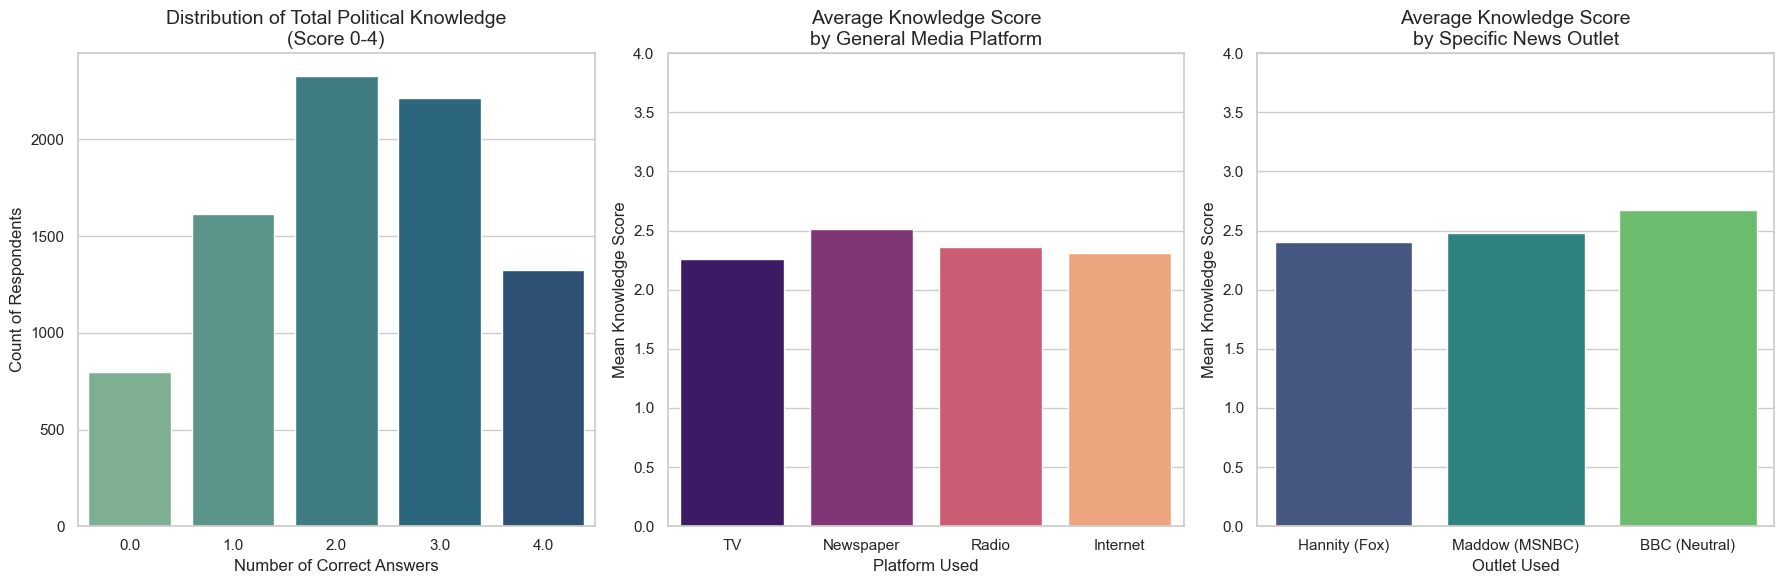

In [ ]:
# --- Visualization Preparation ---

# 1. Create a "Total Knowledge Score" (Sum of the 4 recoded binary variables)
knowledge_vars = ["senator_term", "least_fed_spending", "house_majority", "senate_majority"]
model_df_recoded['total_knowledge'] = model_df_recoded[knowledge_vars].sum(axis=1)

# 2. Clean Media Variables: Convert all to binary (1 = Used, 0 = Not Used/Missing)
# This ensures that negative values (-9, -5) or zeros from the original data are grouped correctly
media_all = [
    "tv_used", "newspaper_used", "internet_used", "radio_used",
    "sean_hannity_fox", "tucker_carlson_fox", "rachel_maddow_msnbc", "lawrence_odonnell_msnbc",
    "yahoo_site", "bbc_site", "buzzfeed_site",
    "nyt_paper", "usa_today_paper", "wsj_paper", "wash_post_paper"
]

for col in media_all:
    model_df_recoded[col] = np.where(model_df_recoded[col] == 1, 1, 0)

# --- Generate 3 Visualizations ---

plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")

# Visualization 1: Distribution of Overall Political Knowledge
plt.subplot(1, 3, 1)
sns.countplot(data=model_df_recoded, x='total_knowledge', palette="crest")
plt.title('Distribution of Total Political Knowledge\n(Score 0-4)', fontsize=14)
plt.xlabel('Number of Correct Answers', fontsize=12)
plt.ylabel('Count of Respondents', fontsize=12)

# Visualization 2: Knowledge Score by General Media Type
# We compare the mean knowledge score for users of the 4 primary platforms
platforms = ['tv_used', 'newspaper_used', 'radio_used', 'internet_used']
platform_means = [model_df_recoded[model_df_recoded[p] == 1]['total_knowledge'].mean() for p in platforms]
platform_labels = ['TV', 'Newspaper', 'Radio', 'Internet']

plt.subplot(1, 3, 2)
sns.barplot(x=platform_labels, y=platform_means, palette="magma")
plt.title('Average Knowledge Score\nby General Media Platform', fontsize=14)
plt.xlabel('Platform Used', fontsize=12)
plt.ylabel('Mean Knowledge Score', fontsize=12)
plt.ylim(0, 4) # Scale 0 to 4

# Visualization 3: Knowledge Score by Partisan and Neutral Outlets
# Contrast Fox (Hannity), MSNBC (Maddow), and a Neutral/International source (BBC)
partisan_vars = ['sean_hannity_fox', 'rachel_maddow_msnbc', 'bbc_site']
partisan_means = [model_df_recoded[model_df_recoded[p] == 1]['total_knowledge'].mean() for p in partisan_vars]
partisan_labels = ['Hannity (Fox)', 'Maddow (MSNBC)', 'BBC (Neutral)']

plt.subplot(1, 3, 3)
sns.barplot(x=partisan_labels, y=partisan_means, palette="viridis")
plt.title('Average Knowledge Score\nby Specific News Outlet', fontsize=14)
plt.xlabel('Outlet Used', fontsize=12)
plt.ylabel('Mean Knowledge Score', fontsize=12)
plt.ylim(0, 4)

plt.tight_layout()
plt.show()

In [ ]:
# --- 1. Recode Knowledge & Media Variables ---

# Define the Knowledge Score (Sum of the 4 recoded facts)
knowledge_vars = ["senator_term", "least_fed_spending", "house_majority", "senate_majority"]
model_df_recoded['total_knowledge'] = model_df_recoded[knowledge_vars].sum(axis=1)

# Define the source groups
partisan_vars = ["sean_hannity_fox", "tucker_carlson_fox", "rachel_maddow_msnbc", "lawrence_odonnell_msnbc"]
website_vars = ["yahoo_site", "bbc_site", "buzzfeed_site"]
newspaper_vars = ["nyt_paper", "usa_today_paper", "wsj_paper", "wash_post_paper"]

# Helper to clean media variables: 1 means 'Used', anything else means 'Not Used'
all_media = partisan_vars + website_vars + newspaper_vars
for col in all_media:
    model_df_recoded[col] = np.where(model_df_recoded[col] == 1, 1, 0)

# --- 2. Create Combined (Aggregate) Indicators ---
# If a respondent used ANY source in the group, the group value is 1
model_df_recoded['partisan_group'] = model_df_recoded[partisan_vars].max(axis=1)
model_df_recoded['website_group'] = model_df_recoded[website_vars].max(axis=1)
model_df_recoded['newspaper_group'] = model_df_recoded[newspaper_vars].max(axis=1)

# --- 3. Calculate Mean Knowledge Scores ---
group_names = ['Any Partisan Source', 'Any News Website', 'Any Traditional Newspaper']
group_cols = ['partisan_group', 'website_group', 'newspaper_group']

mean_scores = []
for col in group_cols:
    mean_val = model_df_recoded[model_df_recoded[col] == 1]['total_knowledge'].mean()
    mean_scores.append(mean_val)

comparison_results = pd.DataFrame({'Media Category': group_names, 'Average Knowledge Score': mean_scores})
print(comparison_results)

              Media Category  Average Knowledge Score
0        Any Partisan Source                 2.397287
1           Any News Website                 2.410753
2  Any Traditional Newspaper                 2.520104


C:\Users\nicho\AppData\Local\Temp\ipykernel_8036\1641394717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_results, x='Media Category', y='Average Knowledge Score', palette='viridis')


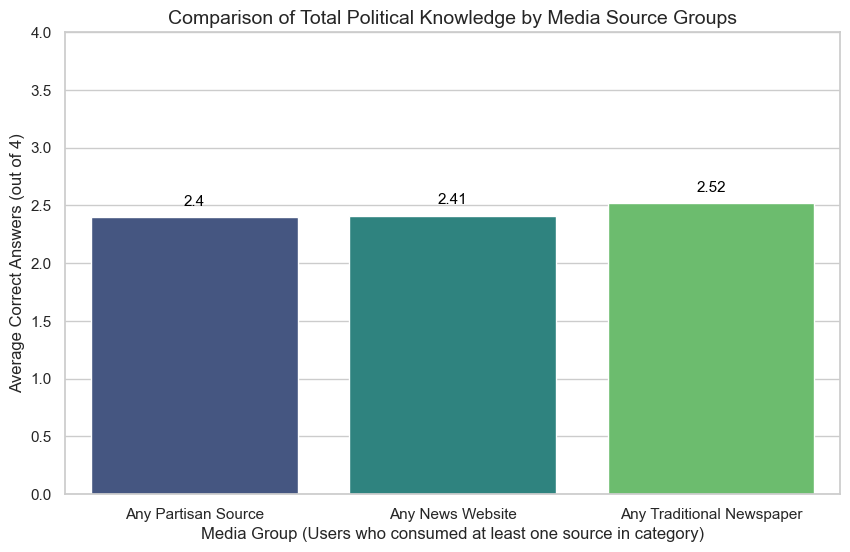

In [ ]:
# --- Visualization: Group Comparison ---
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_results, x='Media Category', y='Average Knowledge Score', palette='viridis')

# Labeling
plt.title('Comparison of Total Political Knowledge by Media Source Groups', fontsize=14)
plt.ylabel('Average Correct Answers (out of 4)', fontsize=12)
plt.xlabel('Media Group (Users who consumed at least one source in category)', fontsize=12)
plt.ylim(0, 4)

# Adding the exact mean labels on top of bars
for index, row in comparison_results.iterrows():
    plt.text(index, row['Average Knowledge Score'] + 0.1, round(row['Average Knowledge Score'], 2), 
             color='black', ha="center", fontsize=11)

plt.show()

---

## Discussion of Survey Design
- How might question wording affect your findings?
- What response biases might be present in this data?
- How do ANES sampling and weighting procedures affect interpretation?
- Compare self-report survey data to behavioral/observational data for your topic